In [ ]:
import urllib.request
import zipfile
import os

try:
    os.mkdir("files")
except:
    pass

with urllib.request.urlopen('https://courses.cs.tau.ac.il/pyProg/2526a/resources/notebook_resources.zip') as f:
    content = f.read()

with open('files/notebook_resources.zip', 'wb') as f:
    f.write(content)

with zipfile.ZipFile('files/notebook_resources.zip', 'r') as zip_ref:
    zip_ref.extractall('files')

print(os.listdir('files'))

# Libraries: Numpy

## Python Programming for Engineers
### Tel-Aviv University / 0509-1820 / Fall 2025-2026

## Agenda: Numpy

- Intorduction
- Matrix operations
- Image processing
    - Basic operations
    - Binary segmentation
    - Ternary segmentation
    - Morphological operators  &emsp;&emsp;&emsp;&emsp;<--- We are here!
    - Denoising
    - Image gradient
    - Image brightening


## Morph by neighbors
- Morphology is a technique for the analysis and processing of geometrical structures
- Morph-by-neighbors (or, morphological) operators change a pixel according to its neighborhood



|||
|--|--|
|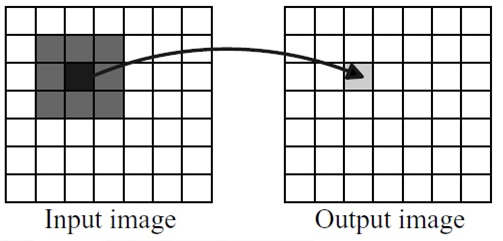|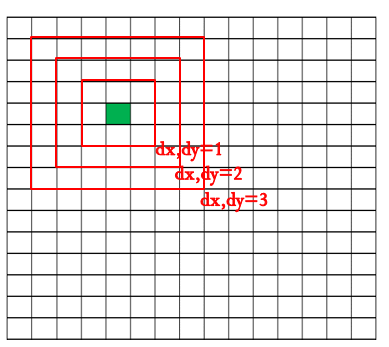
|

### Erosion
- Take **binary image** ; produce **more black, less white**.
    - Edges of white areas (“foreground”) erode away, so black areas (“background”) grow.



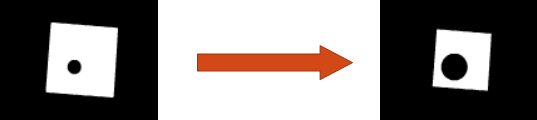

### Dilation – inverse of erosion.
- Boundaries of black areas erode away, so white areas grow.

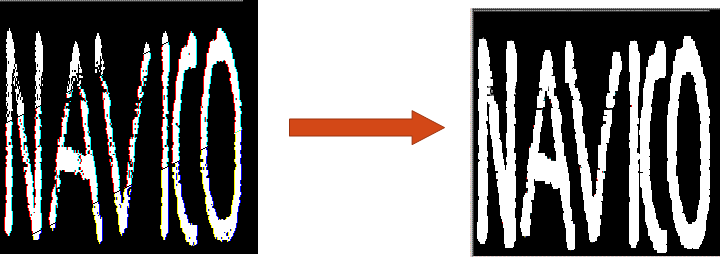

### Implementation

In [ ]:
#Top-down design:
# the "operator" variable is a specific morph function
def morph_by_neighborhood(im, operator, dx=5, dy=5):
    new_im = np.zeros(im.shape)
    for x in range(im.shape[0]):
        for y in range(im.shape[1]):
            neighborhood = get_neighborhood(im,x,y,dx,dy)
            new_im[x, y] = operator(neighborhood)
    return new_im

In [ ]:
def get_neighborhood(im,x,y,dx,dy):
    return im[max(x-dx,0):min(x+dx+1,im.shape[0]), max(y-dy,0):min(y+dy+1,im.shape[1])]
    
def erosion(neighborhood):
    return np.min(neighborhood)
     
def dialation(neighborhood):
    return np.max(neighborhood)

### Erosion - examples

In [ ]:
fname="files/erosion.png"
im = imageio.imread(fname)
im_transformed=morph_by_neighborhood(im,erosion) # Can pass np.min instead of "erosion"
fig,ax=plt.subplots(1,2)
ax[0].imshow(im, cmap=plt.cm.gray)
ax[1].imshow(im_transformed, cmap=plt.cm.gray)

In [ ]:
fname="files/erosion_2.png"
im = imageio.imread(fname)
im_transformed=morph_by_neighborhood(im,np.min)
fig,ax=plt.subplots(1,2)
ax[0].imshow(im, cmap=plt.cm.gray)
ax[1].imshow(im_transformed, cmap=plt.cm.gray)

### Dialation - examples

In [ ]:
fname="files/dialation.png"
im = imageio.imread(fname)
im_transformed=morph_by_neighborhood(im,dialation) # Can pass np.max instead of "erosion"
fig,ax=plt.subplots(1,2)
ax[0].imshow(im, cmap=plt.cm.gray) 
ax[1].imshow(im_transformed, cmap=plt.cm.gray)

In [ ]:
fname="files/dialation_2.png"
im = imageio.imread(fname)
im_transformed=morph_by_neighborhood(im,np.max)
fig,ax=plt.subplots(1,2)
ax[0].imshow(im, cmap=plt.cm.gray)
ax[1].imshow(im_transformed, cmap=plt.cm.gray)

### Detect Edges with Dilation

- Thicken white edges a bit, using dilation
- Compute difference from original image


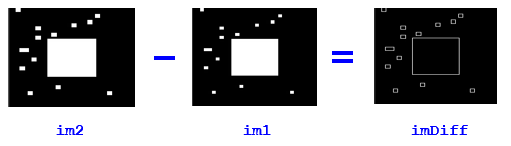

In [ ]:
im1 = imageio.imread('files/erosion_2.png')
im2 = morph_by_neighborhood(im1,dialation, 1, 1)
imDiff = im2 - im1
fig,ax=plt.subplots(1,3)
ax[0].imshow(im1, cmap=plt.cm.gray)
ax[1].imshow(im2, cmap=plt.cm.gray)
ax[2].imshow(imDiff, cmap=plt.cm.gray)

Slides 22-29

## Denoising

### We want to “clean” this pictures from noise. Any suggestions?



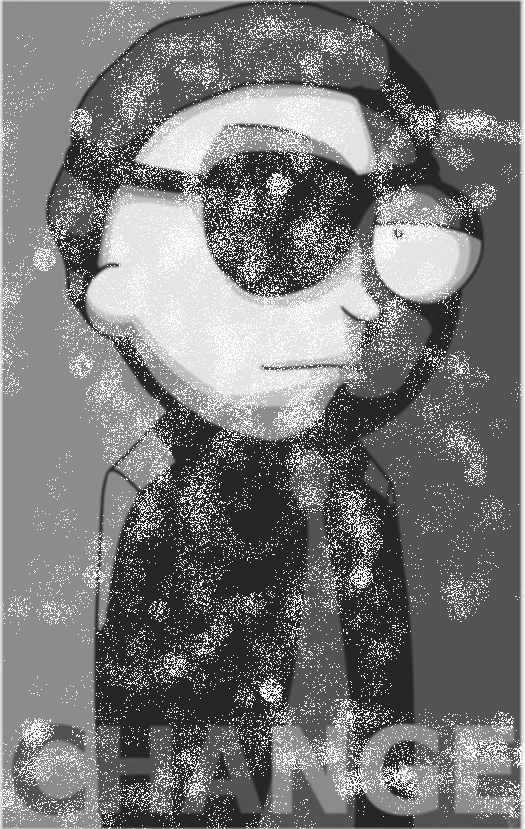

In [ ]:
im = imageio.imread('files/evil_morty_change_noised.png')  

### First attempt: smoothing using `mean`
- Use the morph_by_neighborhood framework with **mean (average)**:

In [ ]:
def denoise_mean(im, dx=5, dy=5):
    return morph_by_neighborhood(im, np.mean, dx, dy) 

In [ ]:
im_transformed=denoise_mean(im)
fig,ax=plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(im, cmap=plt.cm.gray)
ax[1].imshow(im_transformed, cmap=plt.cm.gray)

### Second attempt: smoothing using `median`
- Use the morph_by_neighborhood framework with **m (average)**:

In [ ]:
def denoise_median(im, dx=5, dy=5):
    return morph_by_neighborhood(im, np.median, dx, dy)

In [ ]:
im_transformed=denoise_median(im)
fig,ax=plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(im, cmap=plt.cm.gray)
ax[1].imshow(im_transformed, cmap=plt.cm.gray)

### Can we do better?

- We did not exploit what we know about the ‘noise’
- The ‘noise’ can only be almost white or almost black
    - **So change only "too" bright or "too" dark pixels!**
    - "too" bright and "too" black are determined by predefined thresholds (W, B, respectively)

### solution outline
- Pixels not too bright or too dark remain with no change.
- Otherwise, examine the pixel’s neighborhood neighborhood.
    - too dark:
        - Get the median of neighborhood, but ignore ‘too dark’ pixels
    - too bright:
        - Get the median of neighborhood, but ignore ‘too bright’ pixels

In [ ]:
def my_median(nbrs, min_val=15, max_val=225):
    good_nbrs = nbrs[(nbrs > min_val) & (nbrs < max_val)]
    if good_nbrs.size>0: #There are relevant neighbors
        return np.median(good_nbrs)
    
    #"else": i.e., no relevant neighbors
    center = (nbrs.shape[0]//2, nbrs.shape[1]//2)
    return nbrs[center]


In [ ]:
def clear_noise(nbrs, min_val=15, max_val=225):
    center = (nbrs.shape[0]//2, nbrs.shape[1]//2)
    if not (min_val < nbrs[center] < max_val): #Abnormal pixel
        return my_median(nbrs, min_val, max_val)

    #"else": i.e., a good one, return it
    return nbrs[center]

In [ ]:
def denoise_bounded_median(im, dx=2, dy=2):
    fig,ax=plt.subplots(1,4, figsize=(50,10))
    ax[0].imshow(im, cmap=plt.cm.gray)
    num_repeats = 3
    for i in range(num_repeats): 
        im = morph_by_neighborhood(im, clear_noise, dx, dy)
        ax[i+1].imshow(im, cmap=plt.cm.gray)
    return im

In [ ]:
denoised_image=denoise_bounded_median(im)

In [ ]:
original_image = imageio.imread('files/evil_morty_change.png') 
fig,ax=plt.subplots(1,2, figsize=(20,10))
ax[0].imshow(original_image, cmap=plt.cm.gray)
ax[1].imshow(denoised_image, cmap=plt.cm.gray)

# Self Learning

## Image proccessing

You can represent grayscale images as a two-dimensional `ndarray`, where each element is a number in the range 0-255. A value of 0 represents black, and 255 represents white.

In this exercise, we will convert images into **binary images** (black and white only, without gray levels) and compress their memory footprint.
To achieve this, we will use an algorithm called **Run-Length Encoding (RLE)**.

The RLE algorithm encodes matrices of zeros and ones into numbers that represent the lengths of alternating runs of identical values, assuming that the **first run is a run of zeros**.

Examples:
Consider the following row:

```
00001110001001
```

This row is encoded as:

```
433121
```

Explanation: we have 4 zeros, 3 ones, 3 zeros, 1 one, 2 zeros, 1 one.


Another row:

```
1100001110001001
```

This row is encoded as:

```
02433121
```

Explanation: we start with **0 zeros**, 2 ones, 4 zeros, 3 ones, 3 zeros, 1 one, 2 zeros, 1 one.  
Notice that in this example, the encoding starts with `0` because the row begins with a `1`.
This is because the first number in the encoding always represents how many **leading zeros** appear at the start of the row.

For more details about the RLE algorithm, see the following link:
[https://www.khanacademy.org/computing/computers-and-internet/xcae6f4a7ff015e7d:digital-information/xcae6f4a7ff015e7d:data-compression/a/simple-image-compression](https://www.khanacademy.org/computing/computers-and-internet/xcae6f4a7ff015e7d:digital-information/xcae6f4a7ff015e7d:data-compression/a/simple-image-compression)

**Note:** In all the following parts, you may ignore warnings from the various libraries as long as the code works.

### Exercise 1

Implement the function `binarize_matrix(mat)`.  
The function receives a two-dimensional matrix (the output from part exercise 1) and returns a new binary matrix representing the original pixels in black and white only.
The conversion rule is:

* Pixel values **less than 128** become `0`.
* Pixel values **128 or greater** become `1`.

The function returns a 2D NumPy matrix.

Example run:

```python
>>> img_original = np.array([[10,200,110],[0,205,100]])
>>> img_binarized = binarize_matrix(img_original)
>>> print(img_binarized)
[[0. 1. 0.]
 [0. 1. 0.]]
```

**Hint:** this function can be implemented in one line.

In [ ]:
def binarize_matrix(mat):
    # Write your code here
    pass

### Exercise 2

In this part, we will implement the RLE algorithm with a slight modification.

Implement the function `compress_flatten_rle(mat)`:

* The function receives a binary NumPy matrix (the output of part B).
* It flattens the matrix into a vector using NumPy’s `flatten()` function.
* It then runs the RLE algorithm on the flattened vector (as described in the link above).

Example of flattening:

```python
>>> mat = np.array([[0,1,0],[0,1,0]])
>>> print(mat, mat.shape)
[[0. 1. 0.] 
 [0. 1. 0.]] (2, 3)

>>> mat_flatten = mat.flatten()
>>> print(mat_flatten, mat_flatten.shape)
[0 1 0 0 1 0] (6,)
```

The function `compress_flatten_rle(mat)` returns a tuple containing two elements:

1. A **1D NumPy vector** representing the **compressed** flattened image.
2. A **tuple** containing the original matrix’s `(height, width)`.

**Note:** Try to answer this question without loops, using only numpy functions. 

Example run:

```python
>>> mat_rle_compressed, shape = compress_flatten_rle(img_binarized)
>>> print(mat_rle_compressed, shape)
[1 1 2 1 1] (2, 3)
```


In [ ]:
def compress_flatten_rle(img_binarized):
    # Write your code here
    pass

### Exercise 3


Implement the function `decompress_flatten_rle(mat_rle_compressed, shape)`

The function receives:  
* The compressed flattened image vector (`mat_rle_compressed`)  
* A tuple containing the original matrix dimensions (`shape`)  

The function must reconstruct the binary matrix based on the RLE encoding and return the 2D NumPy matrix.

The output of `decompress_flatten_rle` **must match exactly** the output of `binarize_matrix`.

Example run:

```python
>>> mat_rle_decompressed = decompress_flatten_rle(mat_rle_compressed, shape)
>>> print(mat_rle_decompressed)
[[0. 1. 0.]
 [0. 1. 0.]]
```

In [ ]:
def decompress_flatten_rle(mat_rle_compressed, shape):
    # Write your code here
    pass

### Exercise 4

Implement the function `calc_compression_ratio(compressed, original)`  
The function receives:  
* The compressed representation (the first output of `compress_flatten_rle`)
* The original binary image (output of `binarize_matrix`)

It returns the compression ratio:
$$
\text{compression ratio} =
\frac{\text{number of entries in compressed matrix}}
     {\text{number of entries in original matrix}}
$$

The result must be rounded to **two decimal places**.

Example run:

```python
>>> print(f'calc_compression_ratio: {calc_compression_ratio(mat_rle_compressed, img_binarized)}')
calc_compression_ratio: 0.83
```

In [ ]:
def calc_compression_ratio(compressed, original):
    # Write your code here
    pass

## Numpy: summary

#### Many more operations can be performed on images, in particular:
- Numpy is very convenient library for numerical manipulations
- Can be used for geometric transformations: rotation, flipping, resizing, etc.
- Many application, including image processsing, which we covered thouroughly.